# 01_回归算法-Lasso回归

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/housing.csv`。

转写调整：

- 从本地 housing.csv 构造加州房价特征，删除缺失行，固定抽样 2500 行；load_local_housing(sample_size=None) 可运行全量有效数据。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


最初，给大家分享了线性回归，在这么多模型之后，今天回过头聊聊Lasso回归\~

当然，Lasso回归也是主要用于回归问题。

它的名字来自于“Least Absolute Shrinkage and Selection Operator”的缩写。

Lasso回归是一种线性回归方法，它不仅能找到最佳的预测模型，还能自动选择出最重要的特征。它通过在损失函数中加入一个“惩罚项”来实现这一点。这个惩罚项是所有回归系数的绝对值之和。

那我们为什么要用 Lasso 回归？

**就是在处理数据时，我们经常会遇到很多特征（变量），但不是所有特征都对结果有重要影响。Lasso回归能帮助我们自动筛选出最有用的特征，忽略那些不重要的，这样模型更简单、预测效果更好。**

## 理论基础

Lasso回归就是在普通最小二乘法的基础上增加了一个惩罚项，用于约束模型中的系数，使某些系数变为零，从而实现特征选择。

#### 1. **数学公式**

在普通的线性回归中，我们的目标是找到参数向量 $\mathbf{w}$使得损失函数（即残差平方和）最小化：


$$
\min_{\mathbf{w}} \sum_{i=1}^n (y_i - \mathbf{x}_i^\top \mathbf{w})^2
$$


其中，$\mathbf{x}_i$是第 $i$个样本的特征向量，$y_i$是对应的目标值，$\mathbf{w}$是回归系数向量。

在Lasso回归中，我们在损失函数中添加一个 $L1$正则化项，这个项是所有系数的绝对值之和。Lasso回归的优化目标变为：


$$
\min_{\mathbf{w}} \left( \sum_{i=1}^n (y_i - \mathbf{x}_i^\top \mathbf{w})^2 + \lambda \sum_{j=1}^p |w_j| \right)
$$


其中，$\lambda$是正则化参数，用于控制惩罚项的权重。

#### 2. **公式推理**

为了理解Lasso回归的公式推理，我们需要从优化问题的角度来看。

**普通最小二乘法（OLS）**：

最小化残差平方和：


$$
J(\mathbf{w}) = \sum_{i=1}^n (y_i - \mathbf{x}_i^\top \mathbf{w})^2
$$


**Lasso回归**：

在OLS的基础上，加上一个 $L1$正则化项：


$$
J_{\text{Lasso}}(\mathbf{w}) = \sum_{i=1}^n (y_i - \mathbf{x}_i^\top \mathbf{w})^2 + \lambda \sum_{j=1}^p |w_j|
$$


其中，$\lambda \sum_{j=1}^p |w_j|$是正则化项，它通过增加非零系数的数量来惩罚模型的复杂性。

**梯度下降法**：

为了最小化这个目标函数，我们可以使用梯度下降法。梯度下降的更新规则如下：


$$
\mathbf{w} \leftarrow \mathbf{w} - \alpha \nabla J_{\text{Lasso}}(\mathbf{w})
$$


其中，$\alpha$是学习率，$\nabla J_{\text{Lasso}}(\mathbf{w})$是目标函数的梯度。

计算梯度时，普通最小二乘项的梯度是：


$$
\nabla J_{\text{OLS}}(\mathbf{w}) = -2 \sum_{i=1}^n (y_i - \mathbf{x}_i^\top \mathbf{w}) \mathbf{x}_i
$$


正则化项的梯度稍微复杂一些，因为 $L1$范数的导数在零点不连续。其导数形式是：


$$
\nabla \left( \lambda \sum_{j=1}^p |w_j| \right) = \lambda \text{sign}(w_j)
$$


其中，$\text{sign}(w_j)$表示符号函数。

综合以上两部分，我们得到Lasso回归的梯度：


$$
\nabla J_{\text{Lasso}}(\mathbf{w}) = -2 \sum_{i=1}^n (y_i - \mathbf{x}_i^\top \mathbf{w}) \mathbf{x}_i + \lambda \text{sign}(\mathbf{w})
$$


**注意**：梯度下降法仅是解决这个优化问题的一种方法，也有其他方法如坐标下降法。

#### 3. **算法流程**

下面是Lasso回归的算法流程，假设使用梯度下降法来优化：

1. **初始化参数**：

   - 设置学习率 $\alpha$和正则化参数 $\lambda$。
   - 初始化回归系数 $\mathbf{w}$为零或小的随机值。
2. **迭代更新**：

   - 计算预测值：$\hat{y}_i = \mathbf{x}_i^\top \mathbf{w}$
   - 计算误差：$e_i = y_i - \hat{y}_i$
   - 计算梯度：$\nabla J_{\text{Lasso}}(\mathbf{w}) = -2 \sum_{i=1}^n e_i \mathbf{x}_i + \lambda \text{sign}(\mathbf{w})$
   - 更新参数：$\mathbf{w} \leftarrow \mathbf{w} - \alpha \nabla J_{\text{Lasso}}(\mathbf{w})$
   - 重复上述步骤直到收敛（即参数变化很小或达到最大迭代次数）。
3. **输出结果**：

   - 最终的回归系数 $\mathbf{w}$。

通过上述流程，我们可以得到一个包含最重要特征的稀疏模型。

#### 4. **几何解释**

![原文参考图，当前结果见代码输出](attachments/img_023.png)

假设我们有两个特征 $w_1$和 $w_2$，Lasso 回归的惩罚项 $|w_1| + |w_2|$的几何形状是一个菱形。而 OLS 的等值线是椭圆形。当我们在优化过程中缩小误差平方和的同时约束 $|w_1| + |w_2| \leq C$（即菱形内的区域），最终会导致优化解在菱形的顶点处。这些顶点对应于一些系数（如 $w_1$或 $w_2$）为零，从而实现特征选择。

总之，通过Lasso回归，我们不仅能得到一个适合数据的模型，还能自动筛选出对结果有重要影响的特征，使得模型更加简洁和解释性更强。

## 完整案例

我们使用加利福尼亚房价数据集，该数据集包含了1990年美国加州各个区的房屋价格以及相关的地理和人口统计数据。

这个数据集可以通过 Scikit-learn 库获取，大家不需要额外去寻找\~

**主要步骤**：

1. 加载和探索数据
2. 数据预处理
3. 特征工程
4. 建立和优化 Lasso 模型
5. 模型评估
6. 结果可视化

下面，咱们一步一步来实现，细节的地方大家可以看注释部分。

**1. 加载和探索数据**

首先，我们加载数据并进行初步探索。

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

# 加载数据
from notebook_support import load_local_housing
data = load_local_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target

# 初步查看数据
print(df.head())
print(df.describe())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  3.1838      20.0  3.783465   1.094488       525.0  2.066929     32.79   
1  4.4871       2.0  6.690700   1.166144      3327.0  3.476489     38.01   
2  3.2237      31.0  4.657928   1.064919      2313.0  2.887640     33.92   
3  2.8920      30.0  5.701357   1.248869       707.0  3.199095     37.94   
4  4.1016       4.0  4.709328   1.295011       928.0  2.013015     37.99   

   Longitude  MedHouseVal  
0    -117.24        2.458  
1    -121.29        1.379  
2    -118.14        2.182  
3    -122.07        2.208  
4    -121.89        1.705  
            MedInc     HouseAge     AveRooms    AveBedrms    Population  \
count  2500.000000  2500.000000  2500.000000  2500.000000   2500.000000   
mean      3.812997    28.922400     5.460225     1.108314   1461.117600   
std       1.874065    12.622207     3.412016     0.762000   1214.838324   
min       0.499900     1.000000     0.888889     0.500000      5.000000   


**2. 数据预处理**

处理数据中的缺失值，并进行特征缩放。

In [3]:
# 检查缺失值
print(df.isnull().sum())

# 分离特征和目标变量
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# 数据分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 特征缩放
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


**3. 特征工程**

可视化特征之间的关系以帮助理解数据。

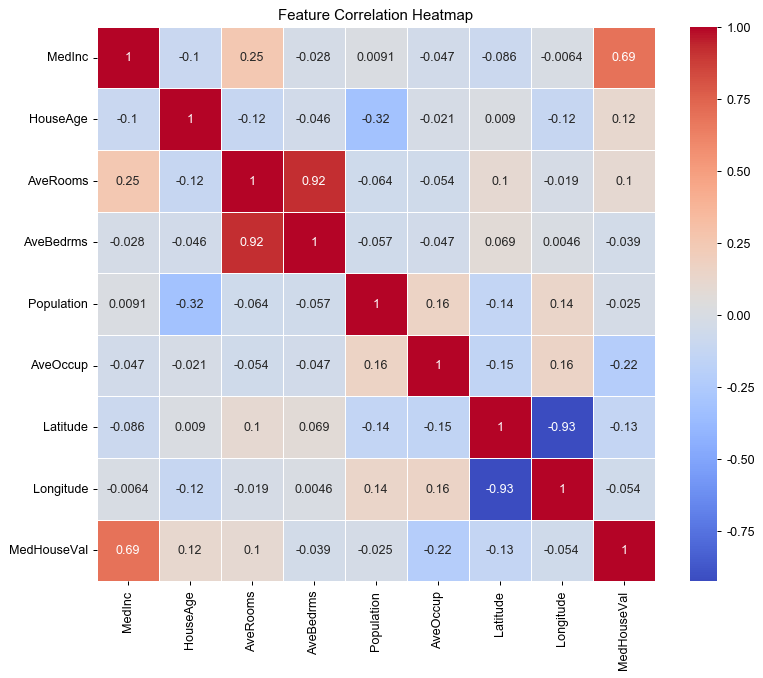

In [4]:
# 特征相关性
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_024.png)

**4. 建立和优化 Lasso 模型**

使用交叉验证和网格搜索优化 Lasso 模型。

In [5]:
# 建立 Lasso 模型
lasso = Lasso()

# 定义超参数网格
param_grid = {'alpha': np.logspace(-4, 4, 50)}

# 网格搜索
grid_search = GridSearchCV(lasso, param_grid, cv=5, scoring='neg_mean_squared_error', error_score='raise')
grid_search.fit(X_train_scaled, y_train)

# 最佳超参数
best_alpha = grid_search.best_params_['alpha']
print(f'Best alpha: {best_alpha}')

# 训练最终模型
lasso_opt = Lasso(alpha=best_alpha)
lasso_opt.fit(X_train_scaled, y_train)

Best alpha: 0.013257113655901081


,alpha,np.float64(0....7113655901081)
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


**5. 模型评估**

评估模型性能，并计算各项指标。

In [6]:
# 预测
y_pred_train = lasso_opt.predict(X_train_scaled)
y_pred_test = lasso_opt.predict(X_test_scaled)

# 评估
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f'MSE (Train): {mse_train}')
print(f'MSE (Test): {mse_test}')
print(f'R^2 (Train): {r2_train}')
print(f'R^2 (Test): {r2_test}')

MSE (Train): 0.5084468973723383
MSE (Test): 0.5038967461948775
R^2 (Train): 0.6308308123649056
R^2 (Test): 0.5991460124092511


**6. 结果可视化**

可视化实际值与预测值之间的关系。

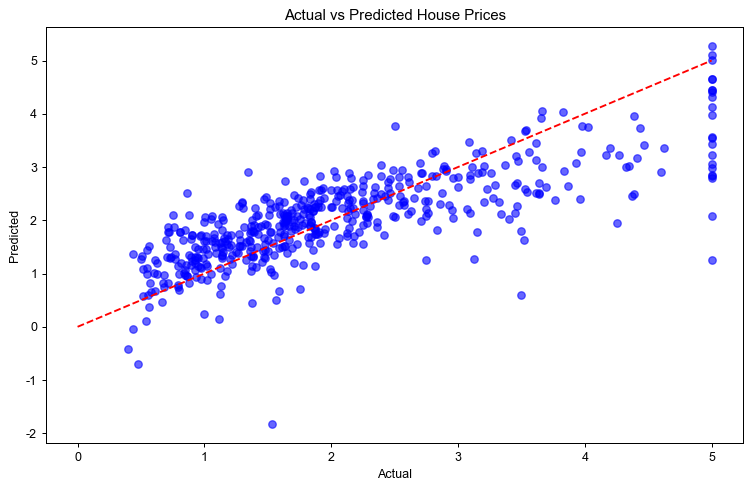

In [7]:
# 可视化
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.6, color='b')
plt.plot([0, 5], [0, 5], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted House Prices')
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_025.png)

其中，有几个点，需要大家注意下\~

1. **数据预处理**：确保所有特征进行标准化，避免特征值差异过大对模型的影响。
2. **参数调整**：使用网格搜索找到最佳的正则化参数 `alpha`。
3. **模型评估**：计算 MSE 和 R² 来评估模型性能，并通过可视化检查预测效果。
4. **特征重要性**：可以查看哪些特征对模型的贡献最大。Lasso 回归会将不重要的特征系数压缩为零，这也可以帮助我们理解特征的重要性。

通过上述整个的过程，大家基本可以全面了解如何使用 Lasso 回归进行房价预测，并且理解原理和代码的实现。最后，并通过优化提升模型性能。

## 模型分析

先来聊聊Lasso回归的优缺点\~

**优点**

1. **特征选择**：Lasso回归会将一些不重要的特征的系数缩减为零，从而实现特征选择。这使得模型更加简洁和易于解释。
2. **减少过拟合**：通过引入正则化项，Lasso回归可以有效地减少过拟合，提高模型的泛化能力。
3. **简单高效**：Lasso回归相对简单，计算效率高，适用于处理高维数据。

**缺点**

1. **多重共线性问题**：当特征之间存在多重共线性时，Lasso回归可能无法正确选择特征，导致模型性能下降。
2. **计算复杂度**：在大规模数据集上，Lasso回归的计算复杂度可能较高，尤其是当使用网格搜索优化超参数时。
3. **模型解释性**：虽然Lasso回归能进行特征选择，但对结果的解释性仍可能受到数据特性的影响，有时难以完全理解模型的行为。

### 与相似算法的对比

| **对比项** | **Ridge回归** (岭回归) | **Elastic Net回归** |
|-|-|-|
| **正则化方式** | 使用 $L2$ 范数（系数的平方和） | 结合了 $L1$ 和 $L2$ 范数的组合 |
| **特征选择** | 不进行特征选择，系数不会被缩减为零 | 能够进行特征选择，同时处理多重共线性问题 |
| **优点** | - 适用于多重共线性问题  <br/>- 不会将系数缩减为零，保留所有特征信息 | - 结合了Lasso和Ridge的优点  <br/>- 既能进行特征选择，又能处理多重共线性问题  <br/>- 更加灵活，适应性强 |
| **缺点** | - 无法进行特征选择，模型可能较复杂  <br/>- 不会丢弃不重要的特征 | - 需要调节两个正则化参数，模型复杂度增加 |
| **适用场景** | - 特征之间存在多重共线性  <br/>- 需要保留所有特征信息时 | - 需要同时处理多重共线性和特征选择问题  <br/>- 数据具有稀疏性时 |
| **调参** | 只需要调整一个正则化参数（正则化强度 $\alpha$） | 需要调整两个正则化参数（$\alpha$ 和 $\lambda$） |
| **模型简洁性** | 由于不进行特征选择，模型可能较为复杂，包含所有特征 | 可以进行特征选择，模型更加简洁，保留重要特征 |
| **计算复杂度** | 计算复杂度相对较低，仅需调整一个参数 | 计算复杂度较高，需要调节两个正则化参数 |

### 使用场景

**适用场景**

- **特征数量多但重要特征少**：Lasso回归非常适合特征数量多，但其中只有少数特征真正重要的情况，因为它可以自动进行特征选择。
- **减少模型复杂度**：在希望模型更加简洁易于解释的场景中，Lasso回归是一个好的选择。
- **防止过拟合**：在数据较少但特征较多的情况下，Lasso回归通过正则化防止过拟合，提高模型的泛化能力。

**其他算法优选场景**

- **多重共线性**：当特征之间存在强烈的多重共线性时，Ridge回归或Elastic Net回归可能更合适，因为Lasso回归在这种情况下可能无法正确选择特征。
- **所有特征都重要**：如果所有特征都对模型预测有贡献，并且不希望丢弃任何特征，可以考虑使用Ridge回归。
- **需要更强的正则化效果**：在特征数量非常庞大的情况下，Elastic Net回归可能提供更好的正则化效果，兼顾特征选择和多重共线性处理。

### 最后

Lasso回归，其实特别适用于高维数据和需要特征选择的场景。然而，在多重共线性严重或需要保留所有特征的情况下，Ridge回归或Elastic Net回归可能是更好的选择。